# Comparing Partitioning Algorithms

Partitioning decides which QPU each logical qubit lives on, and that decision
sets how much **entanglement** the distributed circuit consumes. This notebook
benchmarks every partitioner DQC ships against the same circuit on two
different topologies.

The headline result: **there is no universal winner.** The best algorithm
depends on the network you run it on.

> **Running this notebook.** From the repository root:
>
> ```bash
> uv sync
> uv run jupyter lab demo/comparing_partitioners.ipynb
> ```

## 1. The available algorithms

Pass any of these to `Compiler(..., algo=...)`:

| Name | What it does |
| --- | --- |
| `interaction` | Interaction-graph partitioning, re-partitioning per window (default) |
| `interaction_static` | Interaction-graph partitioning with one fixed assignment |
| `hypergraph` | Hypergraph min-cut partitioning (KaHyPar) |
| `benchmark_static` | Deterministic baseline — fills QPUs in order |
| `benchmark_random` | Random baseline — accepts a `seed` |

The two `benchmark_*` strategies exist as **reference points**: a real
partitioner should beat them, and the margin tells you how much the strategy is
actually buying.

In [1]:
ALGORITHMS = [
    "interaction",
    "interaction_static",
    "hypergraph",
    "benchmark_static",
    "benchmark_random",
]

NETWORKS = {
    "ring_4qpu": "inputs/ring_4qpu.json",
    "chain_3qpu": "inputs/chain_3qpu.json",
}

CIRCUIT = "inputs/qft_12.qasm"

## 2. What we measure

Two numbers, from two stages of the pipeline:

- **e-bit cost** (`compiler.cost`) — total entangled pairs the distributed
  circuit consumes. This is the partitioner's own objective, and it is
  hardware-independent.
- **makespan** — total execution time once scheduled. This depends on hardware,
  so we hold the hardware fixed and let only the partitioner vary.

In [2]:
from memq_dqc import Compiler, Scheduler


def evaluate(circuit, network, algo):
    """Compile and schedule one circuit/network/algorithm combination.

    Args:
        circuit: Path to the OpenQASM circuit.
        network: Path to the network topology.
        algo: Partitioning algorithm name.

    Returns:
        Mapping with the e-bit cost and the scheduled makespan.
    """
    algo_kwargs = {"seed": 0} if algo == "benchmark_random" else None
    compiler = Compiler(circuit, network, algo=algo, algo_kwargs=algo_kwargs)
    compiler.compile()

    ebits = compiler.cost

    scheduler = Scheduler(
        compiler,
        algo="des_link_fifo",
        modality="neutral_atom",
        entanglement_profile="demo.demo",
        algo_kwargs={"seed": 0},
    )
    scheduler.run()

    return {
        "ebits": ebits,
        "makespan": scheduler.schedule.makespan,
    }


results = {
    name: {algo: evaluate(CIRCUIT, path, algo) for algo in ALGORITHMS}
    for name, path in NETWORKS.items()
}
print("evaluated", len(ALGORITHMS), "algorithms on", len(NETWORKS), "networks")

evaluated 5 algorithms on 2 networks


## 3. Results

In [3]:
for name in NETWORKS:
    print(f"{name}  (circuit: qft_12)")
    print(f"  {'algorithm':<20} {'e-bits':>8} {'makespan (us)':>15}")
    print("  " + "-" * 45)
    best = min(results[name].values(), key=lambda r: r["ebits"])["ebits"]
    for algo in ALGORITHMS:
        row = results[name][algo]
        marker = "  <-- best" if row["ebits"] == best else ""
        print(
            f"  {algo:<20} {row['ebits']:>8.0f} "
            f"{row['makespan']:>15.1f}{marker}"
        )
    print()

ring_4qpu  (circuit: qft_12)
  algorithm              e-bits   makespan (us)
  ---------------------------------------------
  interaction                90          1476.6
  interaction_static         96          1557.8
  hypergraph                 66          1118.4  <-- best
  benchmark_static           84          1464.4
  benchmark_random           94          1579.2

chain_3qpu  (circuit: qft_12)
  algorithm              e-bits   makespan (us)
  ---------------------------------------------
  interaction                36           843.0  <-- best
  interaction_static         36           809.2  <-- best
  hypergraph                 45           786.8
  benchmark_static           36           822.4  <-- best
  benchmark_random           36           825.0  <-- best



### Reading the table

Look at which algorithm wins on each network — it is not the same one.

On the **ring**, `hypergraph` finds a genuinely better cut than everything
else. On the **chain**, it is the *worst* of the five, and the trivial
`benchmark_static` baseline ties for first.

That is the whole reason this library exists: partitioning quality is a
property of the *algorithm-topology pair*, not of the algorithm alone. Any
claim that one partitioner is "best" has to name the network it was measured
on.

Also note the two baselines are not always bad. On the chain, a QFT's
interaction pattern happens to line up with filling QPUs in index order, so the
naive assignment is hard to beat. A partitioner that cannot beat
`benchmark_static` on your workload is not earning its complexity.

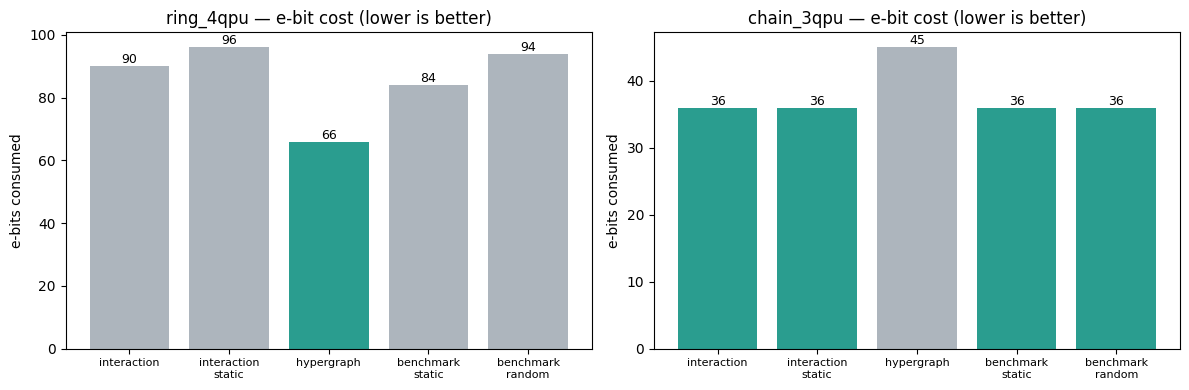

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
short = [a.replace("_", "\n") for a in ALGORITHMS]

for ax, (name, rows) in zip(axes, results.items(), strict=True):
    values = [rows[a]["ebits"] for a in ALGORITHMS]
    lowest = min(values)
    colors = ["#2a9d8f" if v == lowest else "#adb5bd" for v in values]
    ax.bar(short, values, color=colors)
    ax.set_title(f"{name} — e-bit cost (lower is better)")
    ax.set_ylabel("e-bits consumed")
    ax.tick_params(axis="x", labelsize=8)
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig("outputs/partitioner_comparison.png", dpi=150)
plt.show()

## 4. Correctness is not optional

A partitioner that produces a cheap-but-wrong circuit is useless, so verify
each one. `compiler.verify()` rewrites the distributed circuit back to an
equivalent monolithic circuit, simulates both, and compares the output
distributions.

In [5]:
for algo in ALGORITHMS:
    algo_kwargs = {"seed": 0} if algo == "benchmark_random" else None
    compiler = Compiler(
        CIRCUIT,
        NETWORKS["chain_3qpu"],
        algo=algo,
        algo_kwargs=algo_kwargs,
    )
    compiler.compile()
    print(
        f"{algo:<20} e-bits={compiler.cost:>6.0f}  verified={compiler.verify()}"
    )

interaction          e-bits=    36  verified=True


interaction_static   e-bits=    36  verified=True


hypergraph           e-bits=    45  verified=True


benchmark_static     e-bits=    36  verified=True


benchmark_random     e-bits=    36  verified=True


## 5. Benchmarking your own algorithm

`algo` also accepts a class or a preconfigured instance, so a new strategy
drops into the same comparison without touching library code. Subclass the
partitioner base class, then pass it directly:

```python
from memq_dqc.partition import Partitioner

partitioner = Partitioner(network, program, algo=MyPartitioner)
```

The same works through `Compiler(..., algo=MyPartitioner)`. Everything in the
table above — cost accounting, scheduling, verification — then applies to your
algorithm unchanged.

## What you produced

| File | What it is |
| --- | --- |
| `outputs/partitioner_comparison.png` | e-bit cost per algorithm, per topology |

## Next

- **`scheduling_and_hardware.ipynb`** — hold the partitioner fixed and vary the
  hardware instead.
- **`visualization.ipynb`** — see what a partition actually looks like.